In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_csv(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    # ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1

def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, np.abs(Y / len(y))

def get_peak_freq(t, y):
    # mask = t > 0
    # f, Y = compute_fft(t[mask], y[mask])
    f, Y = compute_fft(t, y)
    Y = np.abs(Y)
    return np.abs(f[np.argmax(Y)]) / 1e6

In [208]:
# answers = [ 5.373296, 38.923847 33.074005 22.505043 22.217746 43.071298  5.211336
#  35.171034 10.872007  5.61469 ]

def make_t(sample_rate_returned, num_of_points):

    sample_rate = sample_rate_returned / 4
    dt = (1 / sample_rate)
    t = np.arange(-num_of_points / 2, num_of_points / 2, 1) * dt 
    return t

def make_t_2(start_t, end_t, num_of_points):
    t = np.linspace(start_t, end_t, num_of_points)
    return t

t = make_t(2.5e9, 10000)

wave = np.load(f"./data/waveforms.npy")


for i in range(100):
    ch1 = wave[i]
    freq = get_peak_freq(t, ch1)
    print(freq)
    # if (i % 5 == 1):
    #     print(freq - 5.373296 > 1)
    #     print(freq)
    # if (i % 5 == 2):
    #     print(freq - 38.923847 > 1)
    # if (i % 5 == 3):
    #     print(freq - 33.074005 > 1)
    # if (i % 5 == 4):
    #     print(freq - 22.505043 > 1)
    # if (i % 5 == 0):
    #     print(freq - 22.217746 > 1)

5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831


38.93749999999708


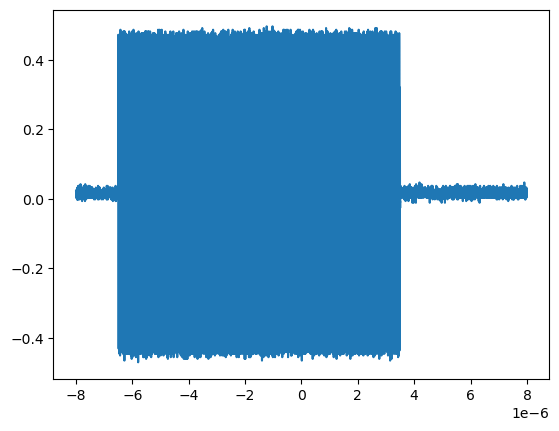

In [30]:
ch1 = np.load(f"./data/raw.npy")
freq = get_peak_freq(t, ch1)
fig, ax = plt.subplots()
ax.plot(t, ch1)
print(freq)


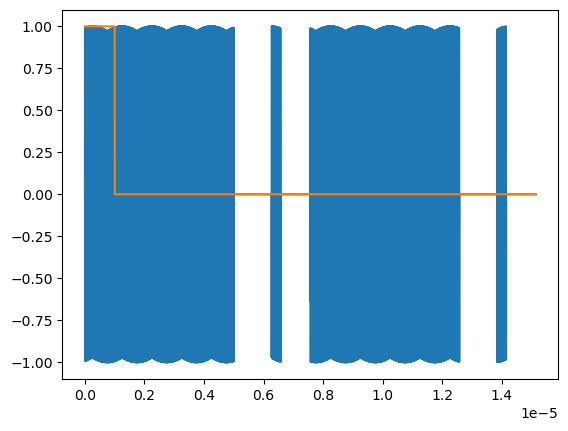

In [3]:
def load_csv_two_channels(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1, ch2

t, ch1, ch2 = load_csv_two_channels("./waveforms/test.csv")
fig, ax = plt.subplots()
ax.plot(t, ch1)
ax.plot(t, ch2)
# ax.set_xlim(0, 1e-5)

1.0303999999988767e-05


(0.0, 5e-07)

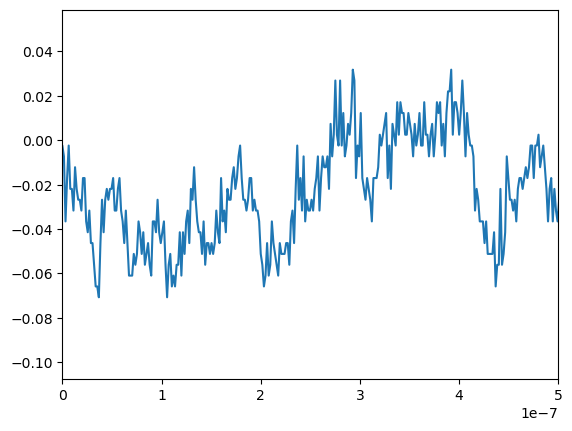

In [44]:
timetable = np.load("./data/timetable.npy")
print(timetable[1] - timetable[0])

t = make_t(2.5e9, 10000)
test = np.load("./data/test.npy")
fig, ax = plt.subplots()
ax.plot(t, test[5])
ax.set_xlim([0, 5e-7])

(0.0, 5e-07)

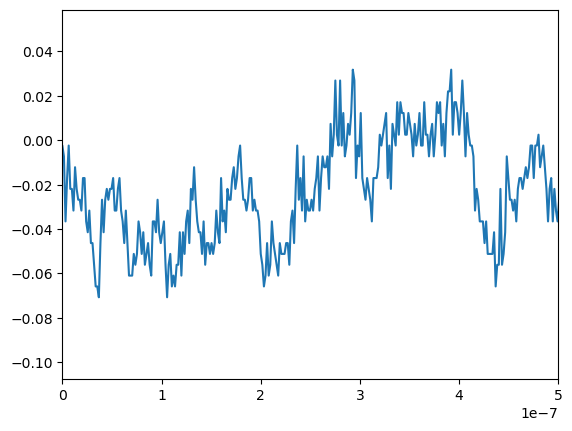

In [45]:

t = make_t(2.5e9, 10000)
test = np.load("./data/test.npy")
fig, ax = plt.subplots()
ax.plot(t, test[5])
ax.set_xlim([0, 5e-7])

0.011253906


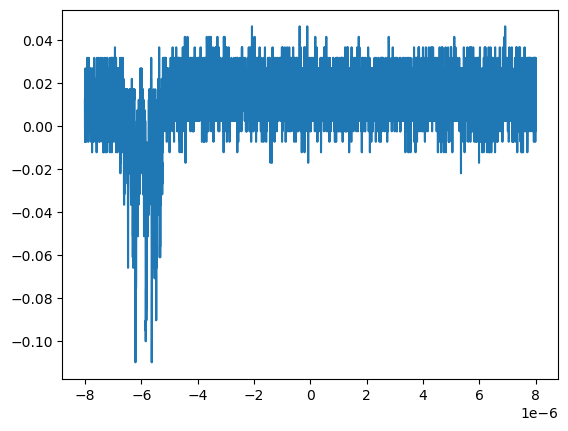

In [168]:
t = make_t(2.5e9, 10000)
test = np.load("../data/t1_data_3/1ms_2ms_3ms_4ms_calib_1ms_dark_between.npy")
fig, ax = plt.subplots()
# 3 is the calibration
num = test[3]
ax.plot(t, num)
print(np.average(num))
# ax.set_xlim([0, 5e-7])

[False False False  True False False False False  True False]
[False False False False  True False False False False  True]
[ True False False False False  True False False False False]
[False  True False False False False  True False False False]
[False False  True False False False False  True False False]
-0.016098633
-0.011083818
-0.006660836
-0.0024403771
-0.003624028


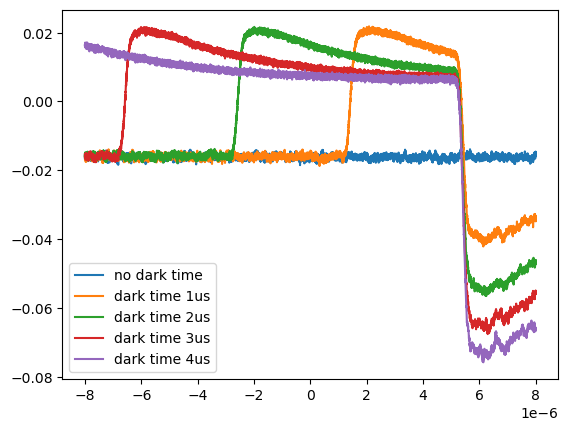

In [ ]:

# might not actually need the factor of 4
t = make_t(2.5e9, 10000)

test = np.load("./t1_data_2/1us_2us_3us_4us_calib.npy")

def average_rotating_signals(arr, first_1_idx):
    idx = np.arange(len(arr))

    averages = []
    for signal in range(5):
        mask = ((idx - first_1_idx) % 5) == signal
        print(mask[:10])
        averages.append(arr[mask].mean(axis=0))

    return tuple(averages)
avg_1, avg_2, avg_3, avg_4, avg_5 = average_rotating_signals(test, 3)

fig, ax = plt.subplots()
ax.plot(t, avg_1, label="no dark time")
print(np.average(avg_1))
ax.plot(t, avg_2, label="dark time 1us")
print(np.average(avg_2))
ax.plot(t, avg_3, label="dark time 2us")

print(np.average(avg_3))
ax.plot(t, avg_4, label="dark time 3us")
print(np.average(avg_4))
ax.plot(t, avg_5, label="dark time 4us")
print(np.average(avg_5))
# ax.set_xlim([0, 5e-7])
plt.legend()

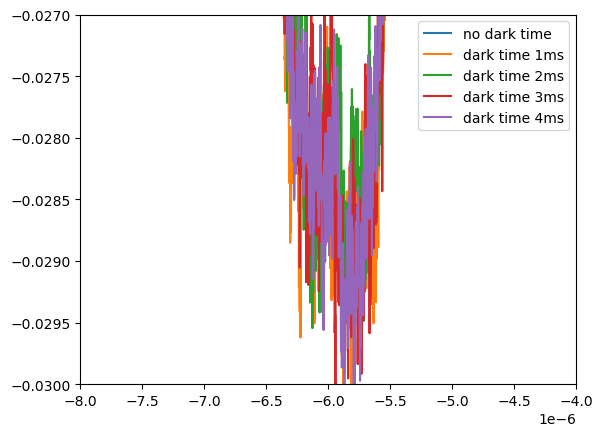

In [ ]:
# test = np.concatenate(()
test1 = np.load("../data/t1_data_3/1ms_2ms_3ms_4ms_calib_1ms_dark_between.npy")
test2 = np.load("../data/t1_data_3/1ms_2ms_3ms_4ms_calib_1ms_dark_between_2.npy")


def average_rotating_signals(arr, first_1_idx, num_rotate=5):
    idx = np.arange(len(arr))

    averages = []
    for signal in range(num_rotate):
        mask = ((idx - first_1_idx) % num_rotate) == signal
        averages.append(arr[mask].mean(axis=0))

    return averages
    
averages_1 = average_rotating_signals(test1, 1, 5)
averages_2 = average_rotating_signals(test2, 2, 5)
averages = np.mean([averages_1, averages_2], axis=0)

fig, ax = plt.subplots()
ax.plot(t, averages[0], label="no dark time")
ax.plot(t, averages[1], label="dark time 1ms")
ax.plot(t, averages[2], label="dark time 2ms")

ax.plot(t, averages[3], label="dark time 3ms")
ax.plot(t, averages[4], label="dark time 4ms")
ax.set_ylim([-0.03, -0.02])
ax.set_xlim([-8e-6, -4e-6])
plt.legend()

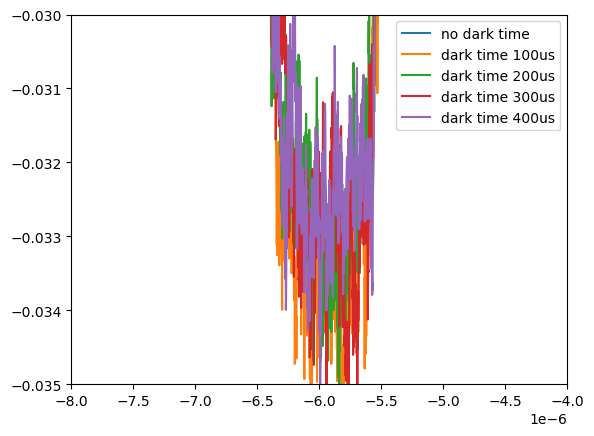

In [206]:
# test = np.concatenate(()
test1 = np.load("../data/t1_data_3/100us_200us_300us_400us_calib_1ms_dark_between.npy")


averages = average_rotating_signals(test1, 1, 5)
# averages_2 = average_rotating_signals(test2, 2, 5)
# averages = np.mean([averages_1, averages_2], axis=0)

fig, ax = plt.subplots()
ax.plot(t, averages[0], label="no dark time")
ax.plot(t, averages[1], label="dark time 100us")
ax.plot(t, averages[2], label="dark time 200us")

ax.plot(t, averages[3], label="dark time 300us")
ax.plot(t, averages[4], label="dark time 400us")
ax.set_ylim([-0.035, -0.03])
ax.set_xlim([-8e-6, -4e-6])
plt.legend()

C:\Users\codin\AppData\Local\Temp\ipykernel_17272\763259451.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


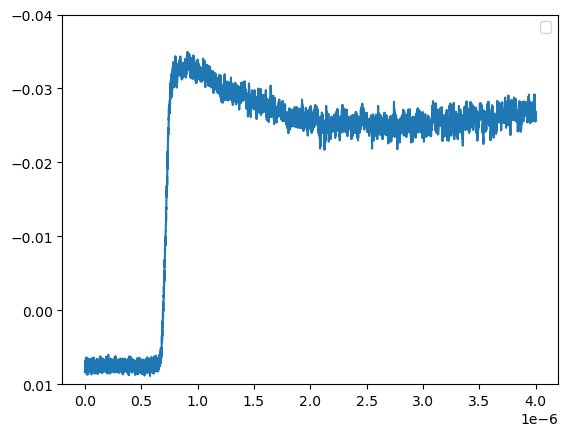

In [219]:
test = np.load("../data/t1_data_3/20ms_on_20ms_off.npy")
t = make_t_2(0, 4e-6, 10000)

averages = np.average(test, axis=0)

fig, ax = plt.subplots()
ax.plot(t, averages)
ax.set_ylim([0.01, -0.04])
plt.legend()